In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools

In [2]:
fontsize = 16
fontsize_minor = 12

In [3]:
model_names_mapper = {
    'llava-1.5-7b': 'LLaVA1.5-Vicuna-7B', 
    'llava-v1.6-vicuna-7b': 'LLaVA1.6-Vicuna-7B', 
    'llava-v1.6-mistral-7b': 'LLaVA1.6-Mistral-7B', 
    'molmoD-7B': 'MolmoD-7B', 
    'Qwen2.5-VL-3B': 'Qwen2.5-VL-3B', 
    'Qwen2.5-VL-7B': 'Qwen2.5-VL-7B',
    'Qwen3-VL-4B-Instruct': 'Qwen3-VL-Instruct-4B',
    'Qwen3-VL-8B-Instruct': 'Qwen3-VL-Instruct-8B',
}

../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_red_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_red_3.csv


/tmp/ipykernel_284828/3382089753.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3382089753.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(


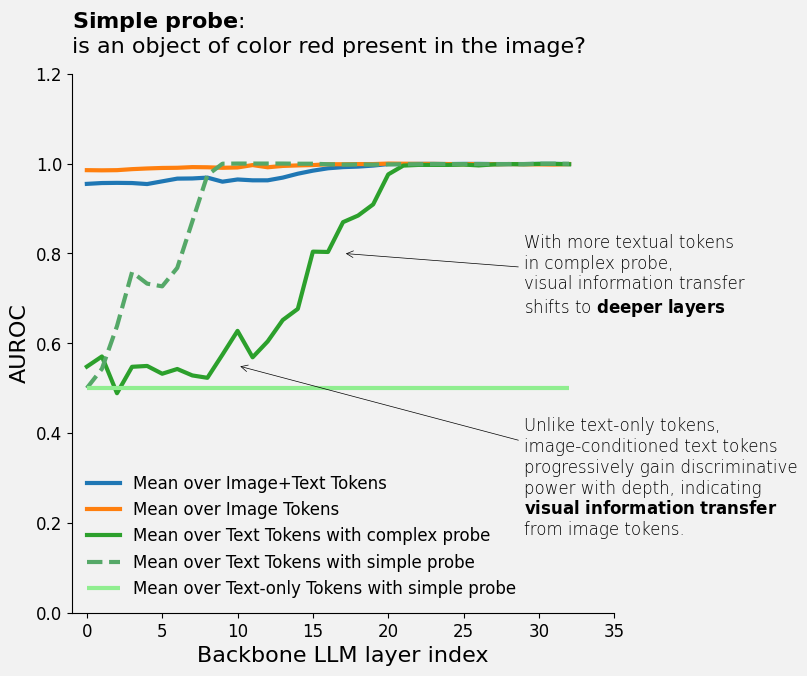

In [7]:
# results_path = '../../results/llava-1.5-7b/linear_probing/archive/image/'

results_path = '../../results/llava-1.5-7b/linear_probing/probe_image/'
metric = 'auroc'

prompt_type = 'complex'
task = ['color']
target = 'red'
nobjects = 3

fig,axs = plt.subplots(
    nrows=1, 
    ncols=1, 
    figsize=(7, 7)
)

axs = [axs]
hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens with {prompt_type} probe',
    'img': 'Mean over Image Tokens'
}

print(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df['layer'] = list(range(33))*6
plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)

############
prompt_type = 'simple'
hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens with {prompt_type} probe',
    'img': 'Mean over Image Tokens'
}
print(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df_ = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df_['layer'] = list(range(33))*6
plot_df_['embedding over'] = plot_df_['embedding_level'].apply(lambda x: x.split('_')[0])
plot_df_['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df_['embedding_level']]
plot_df_ = plot_df_[plot_df_['embedding over']=='sentence'].reset_index(drop=True)
plot_df_ = plot_df_[plot_df_['hue']==f'Mean over Text Tokens with {prompt_type} probe'].reset_index(drop=True)


b = sns.lineplot(
    data=plot_df, 
    ax=axs[0],
    y=metric, 
    x='layer', 
    hue='hue',
    linewidth=3,
)

sns.lineplot(
    data=plot_df_, 
    ax=b,
    y=metric, 
    x='layer', 
    linestyle="--",   # ← THIS is what you want
    # dashes=True,
    color=sns.color_palette("deep")[2], 
    linewidth=3,
    label=f'Mean over Text Tokens with {prompt_type} probe',
)

b.hlines(
    y=0.5, 
    xmin=0,
    xmax=32,
    color='lightgreen', 
    label='Mean over Text-only Tokens with simple probe',
    linewidth=3,
)

b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
b.set_ylabel(metric.upper(), fontsize=fontsize)

b.set(ylim=(0,1.2), xlim=(-1, 35))

b.set_xticklabels(
    b.get_xticklabels(), 
    fontsize=fontsize_minor,
    rotation_mode="anchor",
)
b.set_yticklabels(
    b.get_yticklabels(), 
    fontsize=fontsize_minor,
)

b.set_title(
    # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
    (
        rf"$\bf{{Simple}}$ $\bf{{probe}}$:"
        "\n"
        f"is an object of {task[0]} {target} present in the image?"
    ),
    loc='left',
    fontsize=fontsize,
    pad=15
)


b.legend(
    frameon=False, 
    fontsize=fontsize_minor,
)

# plt.subplots_adjust(hspace=0.3, wspace=0.3)


axs[0].annotate(
    text=(
        "With more textual tokens\n"
        "in complex probe,\n"
        "visual information transfer\n" 
        rf"shifts to $\bf{{deeper}}$ $\bf{{layers}}$"
        # "Text-only and image-conditioned text\n"
        # r"tokens $\bf{overlap}$"
    ),
    xy=(17, 0.8),          # overlapping region
    xytext=(29, 0.75),
    arrowprops=dict(
        arrowstyle="->", 
        lw=0.5,
        # relpos=(0.4, 0.25), 
    ),
    fontsize=fontsize_minor,
    fontweight=299,
    ha="left",
    va="center",
)

axs[0].annotate(
    text=(
        "Unlike text-only tokens,\n" 
        "image-conditioned text tokens\n"
        "progressively gain discriminative\n" 
        "power with depth, indicating\n"
        r"$\bf{visual}$ $\bf{information}$ $\bf{transfer}$"
        "\nfrom image tokens."
    ),
    xy=(10, 0.55),          # overlapping region
    xytext=(29, 0.3),
    arrowprops=dict(
        arrowstyle="->", 
        lw=0.5,
        # relpos=(0.4, 0.25), 
    ),
    fontsize=fontsize_minor,
    fontweight=299,
    ha="left",
    va="center",
)




axs[0].set_facecolor((0.95, 0.95, 0.95))


# ############For ssimple and complex comparison

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

fig.savefig(
    "./../Figures/LP_red_main.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)



In [8]:
plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
plot_df

,Unnamed: 0,accuracy,auroc,auprc,f1,precision,recall,embedding_level,layer
0,0,0.825243,0.892911,0.894538,0.826923,0.811321,0.843137,sentence_all,0
1,1,0.825243,0.892911,0.895112,0.826923,0.811321,0.843137,sentence_all,1
2,2,0.825243,0.892534,0.894360,0.826923,0.811321,0.843137,sentence_all,2
3,3,0.825243,0.881599,0.885428,0.826923,0.811321,0.843137,sentence_all,3
4,4,0.825243,0.889894,0.893749,0.826923,0.811321,0.843137,sentence_all,4
...,...,...,...,...,...,...,...,...,...
94,28,0.980583,0.999623,0.999623,0.980000,1.000000,0.960784,sentence_text,28
95,29,0.961165,0.998492,0.998506,0.959184,1.000000,0.921569,sentence_text,29
96,30,0.990291,1.000000,1.000000,0.990099,1.000000,0.980392,sentence_text,30
97,31,0.990291,1.000000,1.000000,0.990099,1.000000,0.980392,sentence_text,31


../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_shape_gray_cylinder_7.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_shape_gray_cylinder_7.csv
../../results/llava-v1.6-mistral-7b/linear_probing/probe_image//complex/probing_results_color_shape_gray_cylinder_7.csv
../../results/llava-v1.6-mistral-7b/linear_probing/probe_image//simple/probing_results_color_shape_gray_cylinder_7.csv
../../results/Qwen2.5-VL-3B/linear_probing/probe_image//complex/probing_results_color_shape_gray_cylinder_7.csv
../../results/Qwen2.5-VL-3B/linear_probing/probe_image//simple/probing_results_color_shape_gray_cylinder_7.csv


/tmp/ipykernel_366350/2526380046.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_366350/2526380046.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_366350/2526380046.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_366350/2526380046.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_366350/2526380046.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_366350/2526380046.py:101: UserWarning:

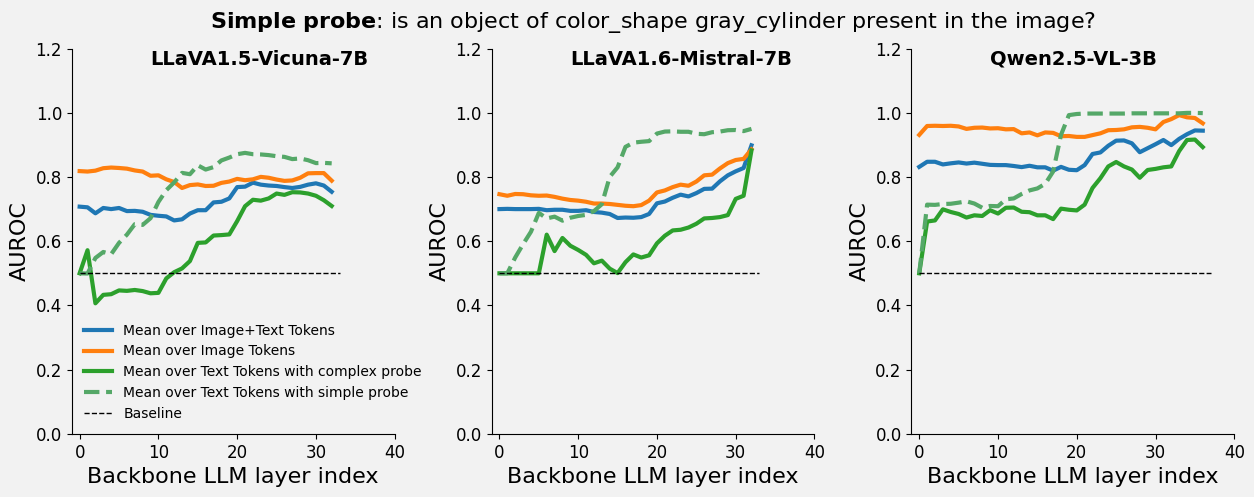

In [44]:

# results_path = '../../results/llava-v1.6-mistral-7b/linear_probing/archive/image/'

model_ls = [
'llava-1.5-7b',
'llava-v1.6-mistral-7b',
'Qwen2.5-VL-3B',
]

fig,axs = plt.subplots(
nrows=1, 
ncols=3, 
figsize=(15, 5)
)

metric = 'auroc'
# task = ['color']
# target = 'red'
# nobjects = 3
# figsavename = "LP_more_models_supp1"

task = ['color_shape']
target = 'gray_cylinder'
nobjects = 7
figsavename = "LP_more_models_supp2"


for idx, model in enumerate(model_ls):
    prompt_type = 'complex'
    results_path = f'../../results/{model}/linear_probing/probe_image/'
    # axs = [axs]
    hue_mapper = {
        'all': 'Mean over Image+Text Tokens',
        'text': f'Mean over Text Tokens with {prompt_type} probe',
        'img': 'Mean over Image Tokens'
    }
    
    print(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
    plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
    # plot_df['layer'] = list(range(33))*6
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
    plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)
    
    ############
    prompt_type = 'simple'
    hue_mapper = {
        'all': 'Mean over Image+Text Tokens',
        'text': f'Mean over Text Tokens with {prompt_type} probe',
        'img': 'Mean over Image Tokens'
    }
    print(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
    plot_df_ = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{'_'.join(task)}_{target}_{nobjects}.csv")
    # plot_df_['layer'] = list(range(33))*6
    plot_df_['embedding over'] = plot_df_['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df_['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df_['embedding_level']]
    plot_df_ = plot_df_[plot_df_['embedding over']=='sentence'].reset_index(drop=True)
    plot_df_ = plot_df_[plot_df_['hue']==f'Mean over Text Tokens with {prompt_type} probe'].reset_index(drop=True)
    
    
    b = sns.lineplot(
        data=plot_df, 
        ax=axs[idx],
        y=metric, 
        x='layer', 
        hue='hue',
        linewidth=3,
    )
    
    sns.lineplot(
        data=plot_df_, 
        ax=b,
        y=metric, 
        x='layer', 
        linestyle="--",   # ← THIS is what you want
        # dashes=True,
        color=sns.color_palette("deep")[2], 
        linewidth=3,
        label=f'Mean over Text Tokens with {prompt_type} probe',
    )
    
    b.hlines(
        y=0.5, 
        xmin=0,
        xmax=len(plot_df_),
        color='black',
        linestyle='--',
        label='Baseline',
        linewidth=1,
    )
    
    b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
    b.set_ylabel(metric.upper(), fontsize=fontsize)
    
    b.set(ylim=(0,1.2), xlim=(-1, 40))
    
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )

    if idx==1:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (
                rf"$\bf{{Simple}}$ $\bf{{probe}}$:"
                " "
                f"is an object of {task[0]} {target} present in the image?"
            ),
            loc='center',
            fontsize=fontsize,
            pad=15
        )
    
    if idx==0:
        b.legend(
            frameon=False, 
            fontsize=fontsize_minor-2,
        )
    else:
        b.legend_.remove()
    b.text(
        9,1.15,
        model_names_mapper[model],
        fontsize=fontsize-2,
        weight='bold',
    )
           
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    axs[idx].set_facecolor((0.95, 0.95, 0.95))
    
    
# ############For ssimple and complex comparison

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)
    
fig.savefig(
    f"./../Figures/{figsavename}.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)
    
    
    


../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_red_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_red_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_blue_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_blue_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_gray_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_gray_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//complex/probing_results_color_green_3.csv
../../results/llava-1.5-7b/linear_probing/probe_image//simple/probing_results_color_green_3.csv


/tmp/ipykernel_284828/3177648326.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3177648326.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/3177648326.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3177648326.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/3177648326.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/3177648326.py:96: UserWarning: se

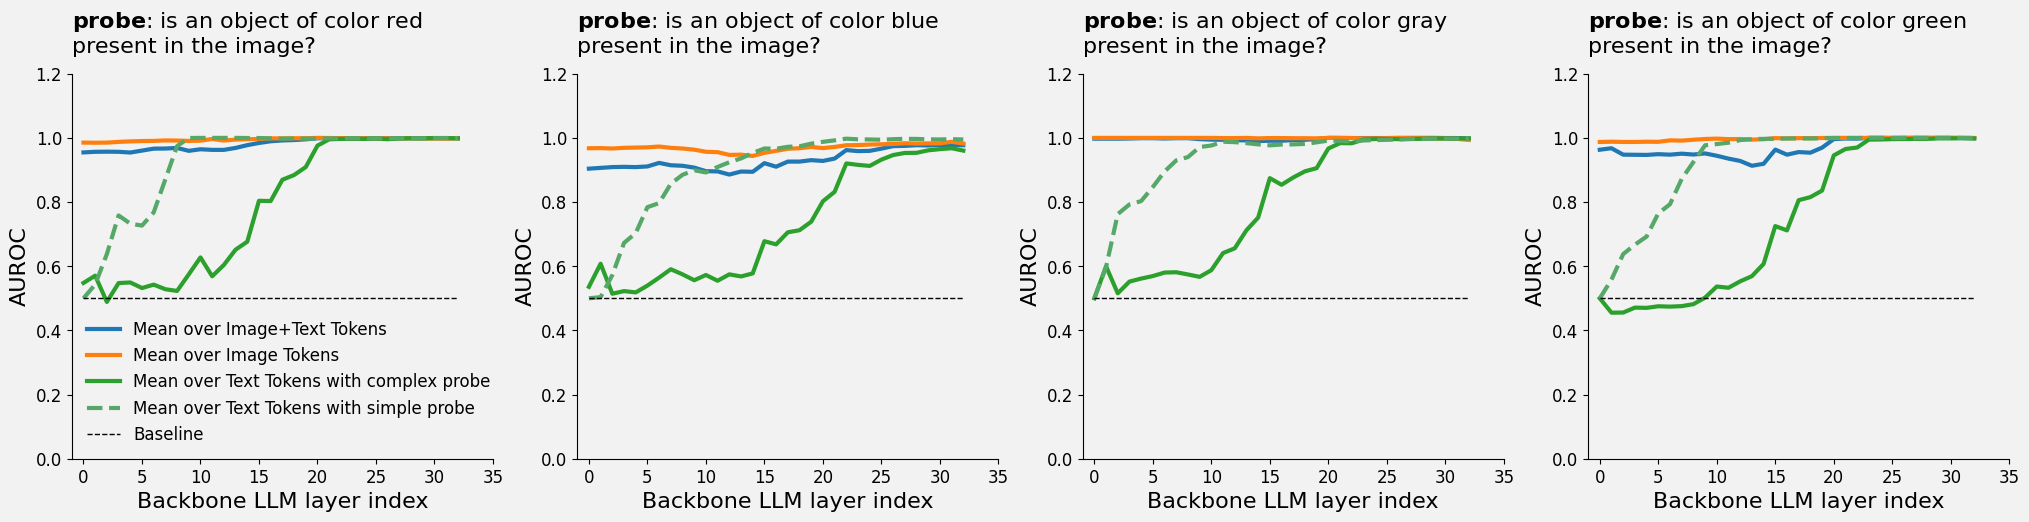

In [86]:
results_path = '../../results/llava-1.5-7b/linear_probing/probe_image/complex/'


# task_ls = ['color']
# target_ls = ['red', 'blue', 'gray', 'green']
# savefigname = 'LP_supp1'

task_ls = ['color_shape']
target_ls = ['blue_cylinder', 'gray_cylinder', 'red_cube', 'green_cube']
savefigname = 'LP_supp2'

nobjects = 3

fig,axs = plt.subplots(
    nrows=1, 
    ncols=4, 
    figsize=(25, 5)
)

for idx, (task, target) in enumerate(list(itertools.product(task_ls, target_ls))):
    results_path = '../../results/llava-1.5-7b/linear_probing/probe_image/'
    metric = 'auroc'
    
    prompt_type = 'complex'
    
    hue_mapper = {
        'all': 'Mean over Image+Text Tokens',
        'text': f'Mean over Text Tokens with {prompt_type} probe',
        'img': 'Mean over Image Tokens'
    }
    
    print(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df['layer'] = list(range(33))*6
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
    plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)
    
    ############
    prompt_type = 'simple'
    hue_mapper = {
        'all': 'Mean over Image+Text Tokens',
        'text': f'Mean over Text Tokens with {prompt_type} probe',
        'img': 'Mean over Image Tokens'
    }
    print(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df_ = pd.read_csv(f"{results_path}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv")
    plot_df_['layer'] = list(range(33))*6
    plot_df_['embedding over'] = plot_df_['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df_['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df_['embedding_level']]
    plot_df_ = plot_df_[plot_df_['embedding over']=='sentence'].reset_index(drop=True)
    plot_df_ = plot_df_[plot_df_['hue']==f'Mean over Text Tokens with {prompt_type} probe'].reset_index(drop=True)
    
    
    b = sns.lineplot(
        data=plot_df, 
        ax=axs[idx],
        y=metric, 
        x='layer', 
        hue='hue',
        linewidth=3,
    )
    
    sns.lineplot(
        data=plot_df_, 
        ax=b,
        y=metric, 
        x='layer', 
        linestyle="--",   # ← THIS is what you want
        # dashes=True,
        color=sns.color_palette("deep")[2], 
        linewidth=3,
        label=f'Mean over Text Tokens with {prompt_type} probe',
    )
    
    b.hlines(
        y=0.5, 
        xmin=0,
        xmax=32,
        color='black', 
        label='Baseline',
        linestyle='--',
        linewidth=1,
    )
    
    b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
    b.set_ylabel(metric.upper(), fontsize=fontsize)
    
    b.set(ylim=(0,1.2), xlim=(-1, 35))
    
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )

    if 'supp1' in figsavename:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (
                rf"$\bf{{probe}}$: is an object of {task} {target}"
                "\n"
                f"present in the image?"
            ),
            loc='left',
            fontsize=fontsize,
            pad=15
        )
    elif 'supp2' in figsavename:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (
                rf"$\bf{{probe}}$: is an object of {task.split('_')[0]} {target.split('_')[0]}"
                "\n"
                f"and {task.split('_')[1]} {target.split('_')[1]} present in the image?"
            ),
            loc='left',
            fontsize=fontsize,
            pad=15
        )

    
    if idx==0:
        b.legend(
            frameon=False, 
            fontsize=fontsize_minor,
        )
    else:
        b.legend_.remove()
    
    # plt.subplots_adjust(hspace=0.3, wspace=0.3)
    
    axs[idx].set_facecolor((0.95, 0.95, 0.95))


# ############For ssimple and complex comparison

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

fig.savefig(
    f"./../Figures/{savefigname}.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)



/tmp/ipykernel_366350/963074219.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_366350/963074219.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_366350/963074219.py:70: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_366350/963074219.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(


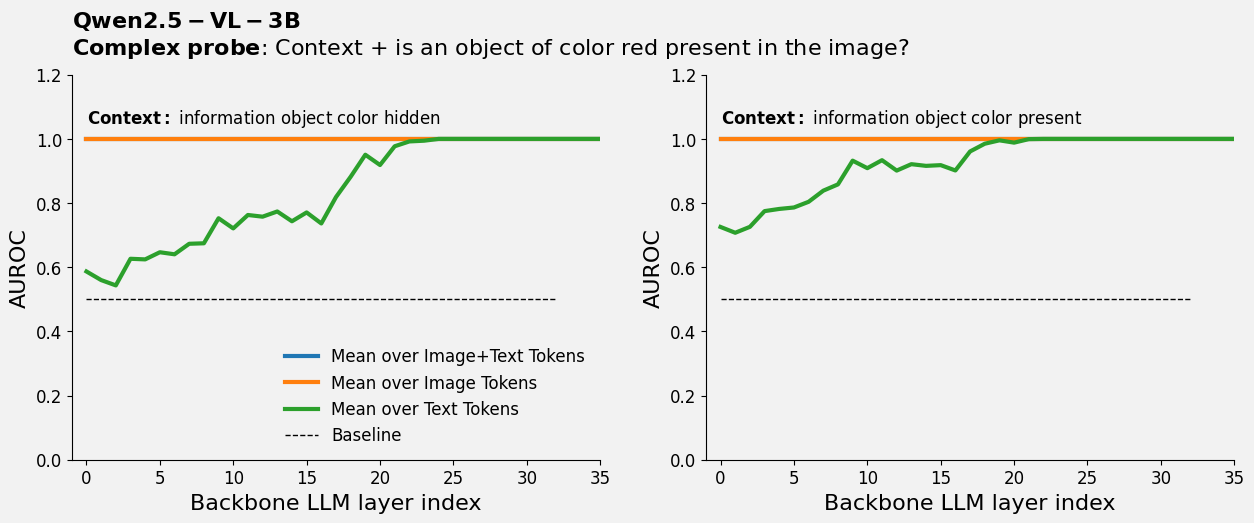

In [71]:
# results_path = '../../results/llava-1.5-7b/linear_probing/archive/image/'

metric = 'auroc'

fig,axs = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(15, 5)
)

# model_ls = [
# 'llava-1.5-7b',
# 'llava-v1.6-mistral-7b',
# 'Qwen2.5-VL-3B',
# ]

model = 'Qwen2.5-VL-3B'

results_paths = [
    f'../../results/{model}/linear_probing/probe_image/complex/probing_results_color_shape_gray_cylinder_7.csv',
    f'../../results/{model}/linear_probing/probe_image_and_text/complex/probing_results_color_shape_gray_cylinder_7.csv'
]

# results_paths = [
#     f'../../results/{model}/linear_probing/probe_image/complex/probing_results_color_red_3.csv',
#     f'../../results/{model}/linear_probing/probe_image_and_text/complex/probing_results_color_red_3.csv'
# ]

hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens',
    'img': 'Mean over Image Tokens'
}

for idx, results_path in enumerate(results_paths):
    
    plot_df = pd.read_csv(results_path)
    # plot_df['layer'] = list(range(33))*6
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
    plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)
    
    b = sns.lineplot(
        data=plot_df, 
        y=metric, 
        x='layer', 
        hue='hue',
        ax=axs[idx],
        linewidth=3,
    )
    
    b.hlines(
        y=0.5, 
        xmin=0,
        xmax=32,
        linestyle='--',
        color='black', 
        label='Baseline',
        linewidth=1,
    )
    
    axs[idx].set_facecolor((0.95, 0.95, 0.95))


    b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
    b.set_ylabel(metric.upper(), fontsize=fontsize)
    
    b.set(ylim=(0,1.2), xlim=(-1, 35))
    
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )


    if idx==0:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (   rf"$\bf{{{model_names_mapper[model]}}}$"
                "\n"
                # rf"$\bf{{Complex}}$ $\bf{{probe}}$: Context + is an object of color red present in the image?" # uncomment for red with qwen 
                rf"$\bf{{Complex}}$ $\bf{{probe}}$: Context + is an object of color gray and shape cylinder present in the image?"
                # "\n"
                # f"is an object of color gray and shape cylinder present in the image?"
            ),
            loc='left',
            fontsize=fontsize,
            pad=15
        )
        
        b.legend(
            loc='lower right',
            frameon=False, 
            fontsize=fontsize_minor,
        )

        axs[idx].text(
            0.02, 1.1,
            rf"$\bf{{Context:}}$ information object color and shape hidden",
            # rf"$\bf{{Context:}}$ information object color hidden", # Uncomment for red qith qwen
            fontsize=fontsize_minor,
            va="top",
        )
            
    elif idx==1:

        axs[idx].text(
            0.02, 1.1,
            # rf"$\bf{{Context:}}$ information object color present",
            rf"$\bf{{Context:}}$ information object color and shape present", # Uncomment for red qith qwen
            fontsize=fontsize_minor,
            va="top",
        )
        
        b.legend_.remove()
    


    axs[idx].set_facecolor((0.95, 0.95, 0.95))

if '1.5' in model:
    axs[1].annotate(
        text=(
            "Probe-relevant information in text\n"
            "tokens boosts accuracy from early layers"
        ),
        xy=(5, 0.6),          # overlapping region
        xytext=(10, 0.3),
        arrowprops=dict(
            arrowstyle="->", 
            lw=0.5,
            # relpos=(0.4, 0.25), 
        ),
        fontsize=fontsize_minor,
        fontweight=299,
        ha="left",
        va="center",
    )

    
fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

# fig.savefig(
#     f"./../Figures/LP_text_image_supp_{model}.png", # add _red at the end for red with qwen 
#     dpi=300,
#     # transparent=True,
#     bbox_inches="tight"
# )



/tmp/ipykernel_284828/1592369136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/1592369136.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/1592369136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/1592369136.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_yticklabels(
/tmp/ipykernel_284828/1592369136.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  b.set_xticklabels(
/tmp/ipykernel_284828/1592369136.py:53: UserWarning: se

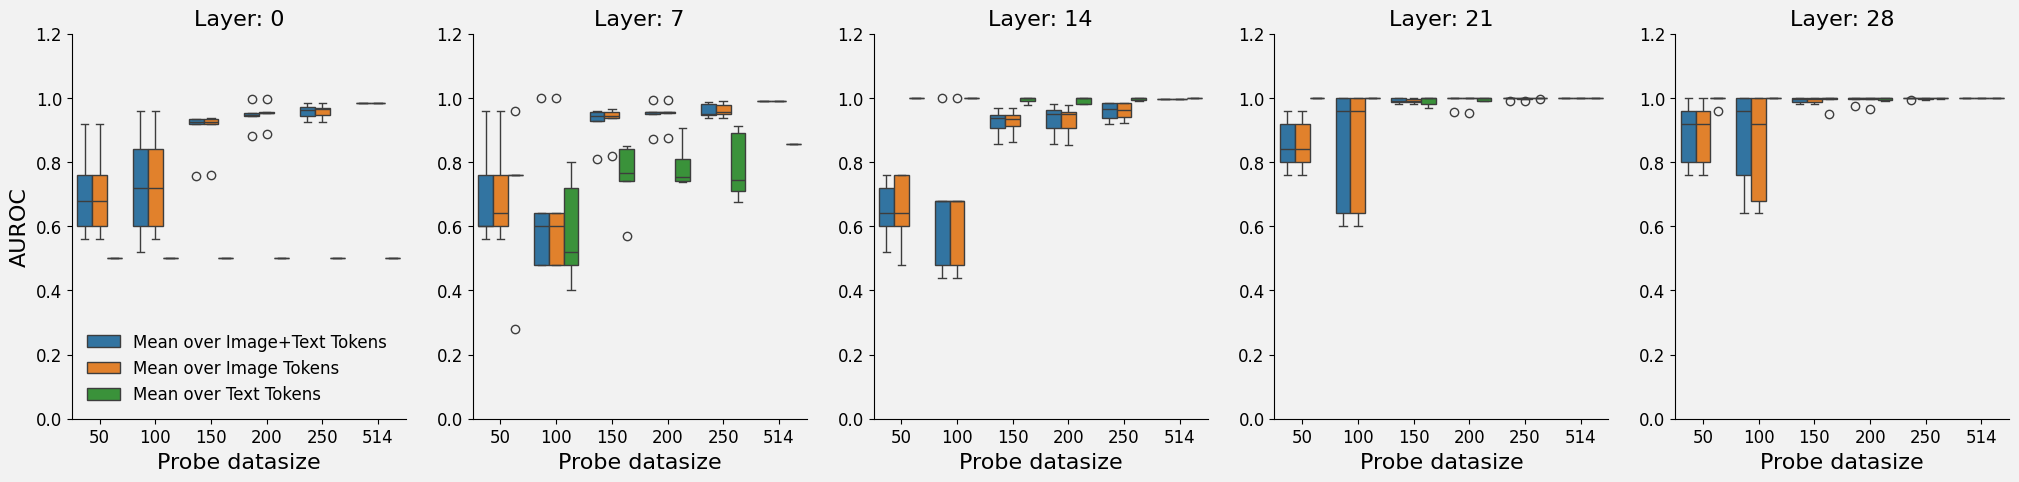

In [111]:
datasize_ls = [50,100,150,200,250,514]
layers = list(range(0,33,7))
metric = 'auroc'
prompt_type = ['simple', 'complex']
task = 'color'
target = 'red'
nobjects = 3

hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens',
    'img': 'Mean over Image Tokens'
}

fig,axs = plt.subplots(nrows=1, ncols=len(layers), figsize=(5*len(layers), 5))

plot_simple_df = []
for datasize in datasize_ls:    
    df = pd.read_csv(f'../../results/llava-1.5-7b/linear_probing/probe_size/{prompt_type[0]}/probing_results_{task}_{target}_{nobjects}_datasize_{datasize}.csv')
    df['probe_datasize'] = [datasize]*len(df)
    plot_simple_df = plot_simple_df + [df]
plot_simple_df = pd.concat(plot_simple_df)
plot_simple_df['embedding over'] = plot_simple_df['embedding_level'].apply(lambda x: x.split('_')[0])
plot_simple_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_simple_df['embedding_level']]

plot_complex_df = []
for datasize in datasize_ls:    
    df = pd.read_csv(f'../../results/llava-1.5-7b/linear_probing/probe_size/{prompt_type[1]}/probing_results_{task}_{target}_{nobjects}_datasize_{datasize}.csv')
    df['probe_datasize'] = [datasize]*len(df)
    plot_complex_df = plot_complex_df + [df]
plot_complex_df = pd.concat(plot_complex_df)
plot_complex_df['embedding over'] = plot_complex_df['embedding_level'].apply(lambda x: x.split('_')[0])


for idx, layer in enumerate(layers):
    b = sns.boxplot(
        data=plot_simple_df[(plot_simple_df['layer']==layer) & (plot_simple_df['embedding over']=='sentence')], 
        ax=axs[idx],
        y=metric, 
        x='probe_datasize', 
        hue='hue',
    )
    b.set(ylim=(0,1.2))
    b.set_title(f"Layer: {layer}", fontsize=fontsize)
    
    b.set_xlabel('Probe datasize', fontsize=fontsize)

    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )
    
    if idx==0:
        b.legend(
            frameon=False, 
            fontsize=fontsize_minor
        )
        b.set_ylabel(metric.upper(), fontsize=fontsize)
    else:
        b.legend_.remove()
        b.set_ylabel('', fontsize=fontsize)
    axs[idx].set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

plt.subplots_adjust(hspace=0.3)

fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

fig.savefig(
    "./../Figures/LP_probe_datasize_supp.png",
    dpi=300,
    # transparent=True,
    bbox_inches="tight"
)



FileNotFoundError: [Errno 2] No such file or directory: '../../results/llava-1.5-7bB/linear_probing/token/probe_image/complex/probing_results_color_shape_gray_cylinder_7.csv'

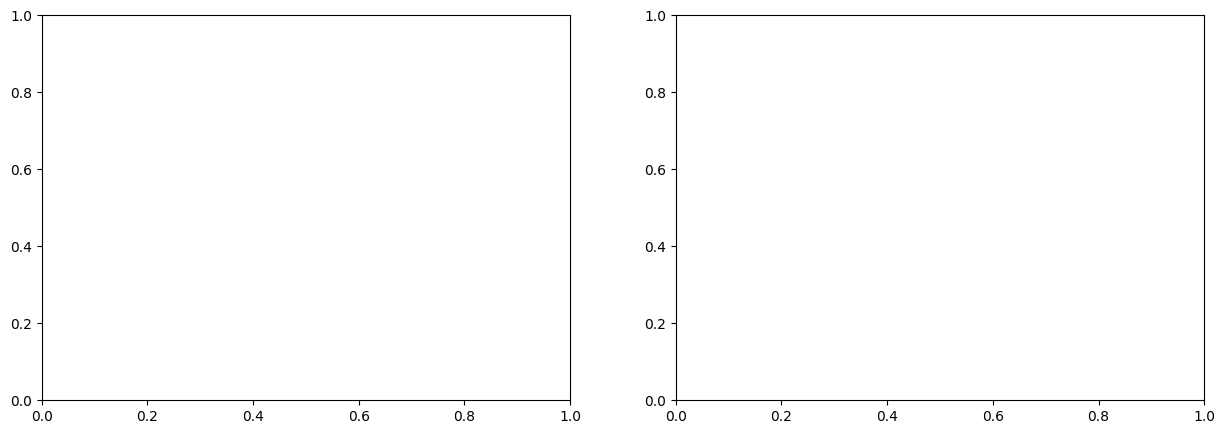

In [6]:
# results_path = '../../results/llava-1.5-7b/linear_probing/archive/image/'

metric = 'auroc'

fig,axs = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(15, 5)
)

# model_ls = [
# 'llava-1.5-7b',
# 'llava-v1.6-mistral-7b',
# 'Qwen2.5-VL-3B',
# ]

model = 'llava-1.5-7bB'

results_paths = [
    f'../../results/{model}/linear_probing/token/probe_image/complex/probing_results_color_shape_gray_cylinder_7.csv',
    f'../../results/{model}/linear_probing/token/probe_image_and_text/complex/probing_results_color_shape_gray_cylinder_7.csv'
]

# results_paths = [
#     f'../../results/{model}/linear_probing/probe_image/complex/probing_results_color_red_3.csv',
#     f'../../results/{model}/linear_probing/probe_image_and_text/complex/probing_results_color_red_3.csv'
# ]

hue_mapper = {
    'all': 'Mean over Image+Text Tokens',
    'text': f'Mean over Text Tokens',
    'img': 'Mean over Image Tokens'
}

for idx, results_path in enumerate(results_paths):
    
    plot_df = pd.read_csv(results_path)
    # plot_df['layer'] = list(range(33))*6
    plot_df['embedding over'] = plot_df['embedding_level'].apply(lambda x: x.split('_')[0])
    plot_df['hue'] = [hue_mapper[i.split('_')[1]] for i in plot_df['embedding_level']]
    plot_df = plot_df[plot_df['embedding over']=='sentence'].reset_index(drop=True)
    
    b = sns.lineplot(
        data=plot_df, 
        y=metric, 
        x='layer', 
        hue='hue',
        ax=axs[idx],
        linewidth=3,
    )
    
    b.hlines(
        y=0.5, 
        xmin=0,
        xmax=32,
        linestyle='--',
        color='black', 
        label='Baseline',
        linewidth=1,
    )
    
    axs[idx].set_facecolor((0.95, 0.95, 0.95))


    b.set_xlabel('Backbone LLM layer index', fontsize=fontsize)
    b.set_ylabel(metric.upper(), fontsize=fontsize)
    
    b.set(ylim=(0,1.2), xlim=(-1, 35))
    
    b.set_xticklabels(
        b.get_xticklabels(), 
        fontsize=fontsize_minor,
        rotation_mode="anchor",
    )
    b.set_yticklabels(
        b.get_yticklabels(), 
        fontsize=fontsize_minor,
    )


    if idx==0:
        b.set_title(
            # rf"$\bf{{Simple}}$ $\bf{{Probe}}$: is an object of {task[0]} {target} present in the image?",
            (   rf"$\bf{{{model_names_mapper[model]}}}$"
                "\n"
                # rf"$\bf{{Complex}}$ $\bf{{probe}}$: Context + is an object of color red present in the image?" # uncomment for red with qwen 
                rf"$\bf{{Complex}}$ $\bf{{probe}}$: Context + is an object of color gray and shape cylinder present in the image?"
                # "\n"
                # f"is an object of color gray and shape cylinder present in the image?"
            ),
            loc='left',
            fontsize=fontsize,
            pad=15
        )
        
        b.legend(
            loc='lower right',
            frameon=False, 
            fontsize=fontsize_minor,
        )

        axs[idx].text(
            0.02, 1.1,
            rf"$\bf{{Context:}}$ information object color and shape hidden",
            # rf"$\bf{{Context:}}$ information object color hidden", # Uncomment for red qith qwen
            fontsize=fontsize_minor,
            va="top",
        )
            
    elif idx==1:

        axs[idx].text(
            0.02, 1.1,
            # rf"$\bf{{Context:}}$ information object color present",
            rf"$\bf{{Context:}}$ information object color and shape present", # Uncomment for red qith qwen
            fontsize=fontsize_minor,
            va="top",
        )
        
        b.legend_.remove()
    


    axs[idx].set_facecolor((0.95, 0.95, 0.95))

if '1.5' in model:
    axs[1].annotate(
        text=(
            "Probe-relevant information in text\n"
            "tokens boosts accuracy from early layers"
        ),
        xy=(5, 0.6),          # overlapping region
        xytext=(10, 0.3),
        arrowprops=dict(
            arrowstyle="->", 
            lw=0.5,
            # relpos=(0.4, 0.25), 
        ),
        fontsize=fontsize_minor,
        fontweight=299,
        ha="left",
        va="center",
    )

    
fig.patch.set_facecolor((0.95, 0.95, 0.95))

sns.despine(top=True, right=True)

# fig.savefig(
#     f"./../Figures/LP_text_image_supp_{model}.png", # add _red at the end for red with qwen 
#     dpi=300,
#     # transparent=True,
#     bbox_inches="tight"
# )

